# Extract Sign Synthetic

New format of the PINN takes `data_edge`, `data_sign`, and `data_phys` as an input. 
This program creates these data for synthetic examples based on MRC file as well as pre-calculated phase field. 

In [1]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import os
import numpy as np
import matplotlib.pyplot as plt
import jax

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [13]:
## To reload

import importlib
# import pinn.cryoet_io as cryoet_io
# import pinn.plot as plot
# import pinn.utils as util
# import data_generation.mesh_to_cryoet as mesh_to_cryoet
import data_generation.preprocess as preprocess

# importlib.reload(cryoet_io)
# importlib.reload(plot)
# importlib.reload(util)
# importlib.reload(mesh_to_cryoet)
importlib.reload(preprocess)

<module 'data_generation.preprocess' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/data_generation/preprocess.py'>

### Parameters

In [72]:
shape = "bud_04"
additive = 0.1
missing  = 0.4

str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')

### Extract Edges
- Input: MRC data (`cryoET_data`)
- Output: `data_edge`

edge:  10033
bulk:  83886


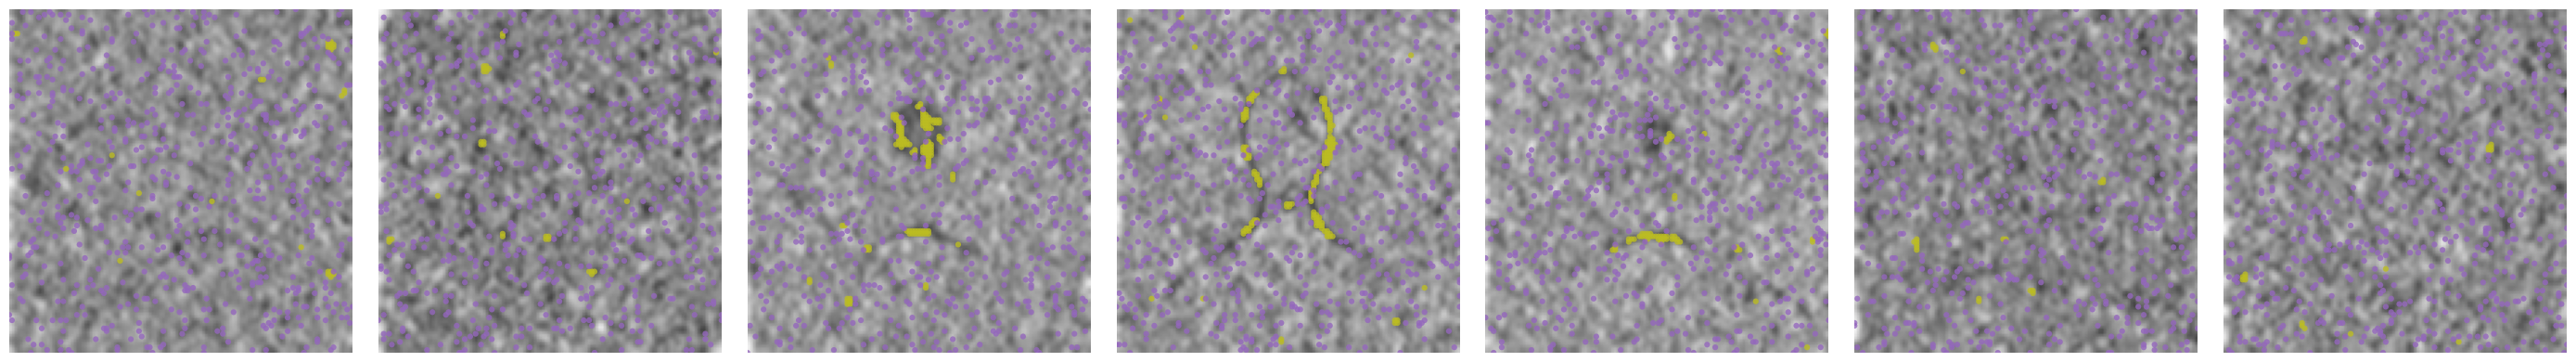

In [75]:
from data_generation.preprocess import downsample_binary_mask_to_fraction, build_data_edge_from_masks, overlay_points_on_cryoet
from pinn.cryoet_io import load_mrc_data
from pinn.utils import save_pts_data

GRID_SIZE = 128
# GRID_SIZE_z = 64
wedge_angle = 60

edge_max = 1.0
edge_min = 0.78
target_edge = 1
target_bulk = 0.04


## ===== LOAD MRC DATA ========
# mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}.mrc"
mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}_wz{wedge_angle}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE, normalize_mrc=True)
# cryoET_data = load_mrc_data(mrc_file_path, grid_size=(GRID_SIZE_z, GRID_SIZE, GRID_SIZE), normalize_mrc=True)

## ===== CALCULATE EDGE AND BULK ========
edge    = (cryoET_data >= edge_min) & (cryoET_data <= edge_max)
bulk    = (~edge)

edge = np.asarray(edge)
bulk = np.asarray(bulk)

edge    = downsample_binary_mask_to_fraction(edge, target_frac=target_edge, seed=0)
bulk    = downsample_binary_mask_to_fraction(bulk, target_frac=target_bulk, seed=0)

edge = edge.astype(np.float32)
bulk = bulk.astype(np.float32)

data_edge = build_data_edge_from_masks(
    edge=edge,
    bulk=bulk,
    volume_shape=cryoET_data.shape,
)

## ===== STORE META DATA ========
meta_edge ={
    "type": "edge",
    "label_meaning": {1: "edge", 0: "bulk"},
    "GRID_SIZE": GRID_SIZE,
    # "GRID_SIZE": (GRID_SIZE_z, GRID_SIZE, GRID_SIZE),
    "wedge_angle": wedge_angle,
    "edge_min": edge_min,
    "edge_max": edge_max,
    "target_edge": target_edge,
    "target_bulk": target_bulk,
    "mrc_path": mrc_file_path,
}

print("edge: ",    (data_edge["label"] == 1).sum())
print("bulk: ",    (data_edge["label"] == 0).sum())

## ===== VISUALIZE DATA ========
slices = list(range(int(GRID_SIZE/8), GRID_SIZE, int(GRID_SIZE/8)))
edge = data_edge["points"][data_edge["label"] == 1][:, [2, 0, 1]]
bulk = data_edge["points"][data_edge["label"] == 0][:, [2, 0, 1]]
overlays = [
    {"data": edge, "label": "Edge", "color": "tab:olive"},
    {"data": bulk, "label": "Bulk", "color": "tab:purple"},
]
# overlay_points_on_cryoet(cryoet=cryoET_data, overlays=overlays, axis='x', slice_index=slices, cryo_alpha=0.8)
overlay_points_on_cryoet(cryoet=cryoET_data, overlays=overlays, axis='z', slice_index=slices, cryo_alpha=0.8)


## ===== SAVE DATA ========
save_data_dir = f"../data/synthetic/pts"
# save_pts_data(data_edge, f"{save_data_dir}/edge/e_{shape}_a{str_add}_m{str_miss}_g{GRID_SIZE}.npz", meta_edge)
# save_pts_data(data_edge, f"{save_data_dir}/edge/e_{shape}_a{str_add}_m{str_miss}_g{GRID_SIZE}_gz{GRID_SIZE_z}.npz", meta_edge)
save_pts_data(data_edge, f"{save_data_dir}/edge/e_{shape}_a{str_add}_m{str_miss}_wz{wedge_angle}.npz", meta_edge)

### Extract Signs and Collocation Points

- Input: pre-calculated phase field
- Output: `data_sign` and `data_phys`

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/ref/checkpoint_10000
positive:  392
nevative:  19608
physics:  40000


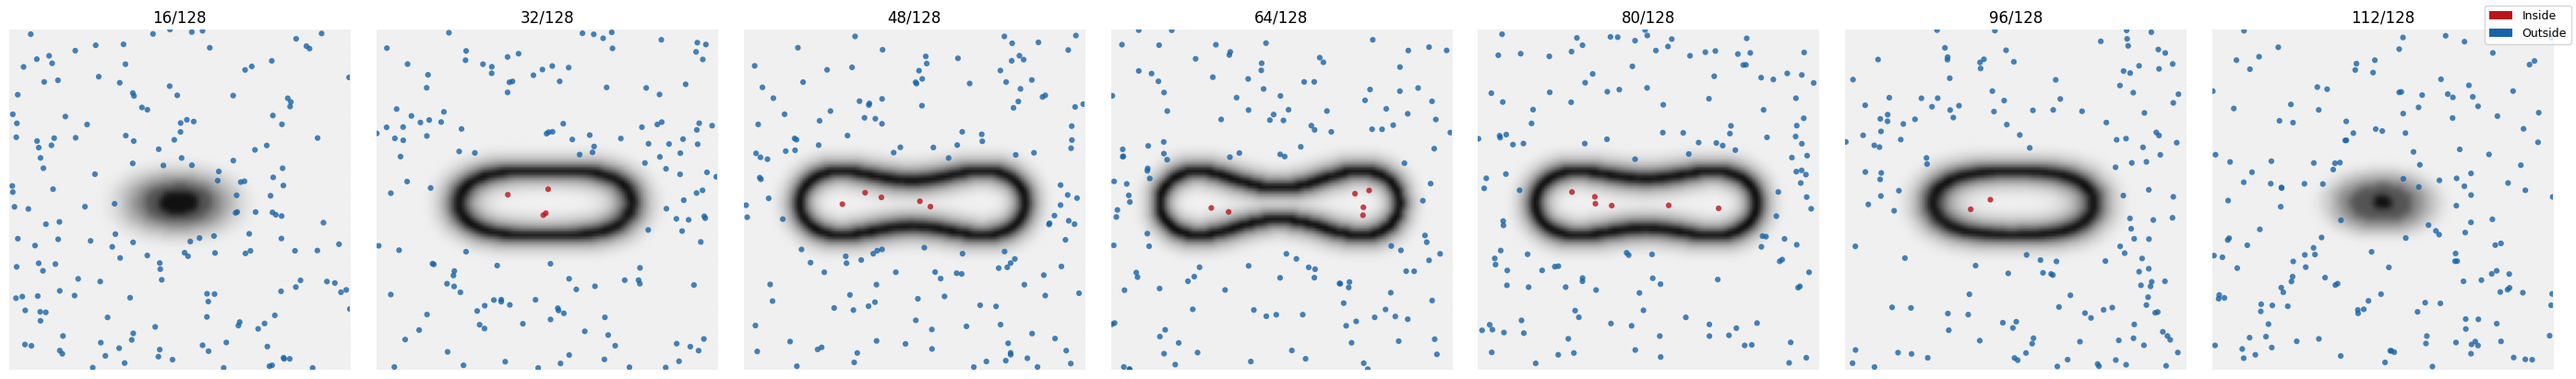

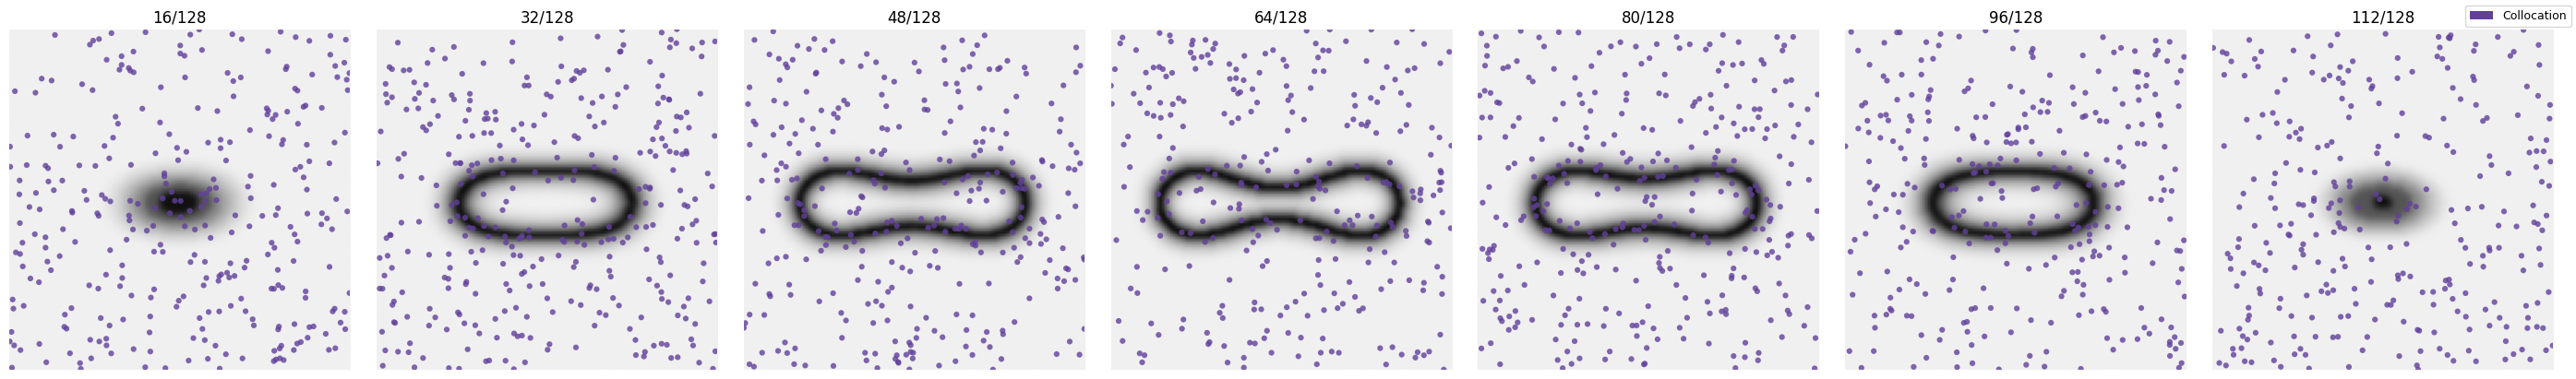

In [52]:
from pinn.utils import sample_sign_points, sample_collocation_points, sample_sign_points_marching_cubes
from flax.training import checkpoints

shape = "biconcave"
num_sign = 20000
num_collocation = 40000
seed = 1
key = jax.random.PRNGKey(seed)
thre_sign = 0.9
sampling_phys = "intensity"
beta_colloc = 1
GRID_SIZE = 128

## ===== LOAD MRC DATA ========
mrc_file_path = f"../data/synthetic/mrc/{shape}_a000_m00.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE, normalize_mrc=True)

# ## ===== LOAD PHASE FIELD ========
data_type = "data_0321"
step = 10000
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/ref")
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
print(checkpoint_path)

## ===== SIGN SAMPLING ========
data_sign = sample_sign_points(checkpoint=checkpoint_data, threshold=thre_sign, n_sample=num_sign)

# ## ===== COLLOCATION POINTS SAMPLING ========
## (A) Uniform sampling
if sampling_phys == "uniform":
    x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))
    data_phys = {"points": x_train}

## (B) Intensity-based sampling
if sampling_phys == "intensity":
    data_phys = sample_collocation_points(key, checkpoint_data, num_collocation, beta=beta_colloc)

# ## ===== STORE META DATA ========
meta_sign ={
    "type": "sign",
    "label_meaning": {1: "postive", -1: "negative"},
    "n_sample": num_sign,
    "threshold": thre_sign,
    "phi_fn": checkpoint_path,
}
meta_phys = {
    "type": "phys",
    "n_sample": num_collocation,
    "seed": seed,
    "sampling": sampling_phys,
    "phi_fn": checkpoint_path,
}

print("positive: ", (data_sign["label"] ==  1).sum())
print("nevative: ", (data_sign["label"] == -1).sum())
print("physics: ", data_phys["points"].shape[0])

## ===== VISUALIZE DATA ========
slices = list(range(int(GRID_SIZE/8), GRID_SIZE, int(GRID_SIZE/8)))
inside  = data_sign["points"][data_sign["label"] ==  1][:, [2, 0, 1]]
outside = data_sign["points"][data_sign["label"] == -1][:, [2, 0, 1]]
overlays = [
    {"data": inside , "label": "Inside",  "cmap": "Reds"},
    {"data": outside, "label": "Outside", "cmap": "Blues"},
]
overlay_points_on_cryoet(cryoet=cryoET_data, overlays=overlays, axis='z', slice_indices=slices, alpha=0.8)

collocation = data_phys["points"][:, [2, 0, 1]]
overlays = [
    {"data": collocation , "label": "Collocation",  "cmap": "Purples"},
]
overlay_points_on_cryoet(cryoet=cryoET_data, overlays=overlays, axis='z', slice_indices=slices, alpha=0.8)


# ## ===== SAVE DATA ========
save_data_dir = f"../data/synthetic/pts"
# save_pts_data(data_sign, f"{save_data_dir}/sign/s_{shape}.npz", meta_sign)
# save_pts_data(data_phys, f"{save_data_dir}/phys/p_{shape}.npz", meta_phys)